# IMPORTS

In [1]:
# 1. Standard library imports
import os

# 2. Third-party imports (Data Science, Visualization, Utilities)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prettytable import PrettyTable
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm

# 3. Deep Learning imports (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models

# DATASET

In [2]:
TRAIN_RATIO = 0.7
TEMP_RATIO = 1 - TRAIN_RATIO
RANDOM_STATE = 42

dataset = pd.read_csv("CSVs/metadata.csv")

assert len(dataset) > 0, "dataset empty, run remove silence first"

# Split 1: train - temp (val + test)
gss_train = GroupShuffleSplit(
    test_size=TEMP_RATIO,
    n_splits=1,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    gss_train.split(
        dataset,
        groups=dataset["actor"]
    )
)

# Split 2: val - test
temp_subset = dataset.iloc[temp_idx]

gss_val = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    gss_val.split(
        temp_subset,
        groups=temp_subset["actor"]
    )
)

train_df = dataset.iloc[train_idx].reset_index(drop=True)
val_df = temp_subset.iloc[val_idx].reset_index(drop=True)
test_df = temp_subset.iloc[test_idx].reset_index(drop=True)

print(f"Train : {len(train_df):>5} samples ({len(train_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(train_df['actor']))}")
print(f"Val   : {len(val_df):>5} samples ({len(val_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(val_df['actor']))}")
print(f"Test  : {len(test_df):>5} samples ({len(test_df) / len(dataset) * 100:.1f}%) - Actors: {len(set(test_df['actor']))}")

def create_csv(df, path):
    df.to_csv(path, index=False)
    
os.makedirs("CSVs", exist_ok=True)

create_csv(train_df, "CSVs/train.csv")
create_csv(val_df, "CSVs/val.csv")
create_csv(test_df, "CSVs/test.csv")

# Check for actor overlap (LEAK)

train_actors = set(train_df["actor"])
val_actors   = set(val_df["actor"])
test_actors  = set(test_df["actor"])

assert train_actors.isdisjoint(val_actors),  "LEAK: actor xuất hiện ở cả train lẫn val!"
assert train_actors.isdisjoint(test_actors), "LEAK: actor xuất hiện ở cả train lẫn test!"
assert val_actors.isdisjoint(test_actors),   "LEAK: actor xuất hiện ở cả val lẫn test!"
print("\nNo actor overlap between splits. Data leakage check passed!")

Train :   960 samples (66.7%) - Actors: 16
Val   :   240 samples (16.7%) - Actors: 4
Test  :   240 samples (16.7%) - Actors: 4

No actor overlap between splits. Data leakage check passed!


# DATA LOADER

In [3]:
# ── Label map ──────────────────────────────────────────────────
EMOTIONS = ["neutral", "calm", "happy", "sad",
            "angry", "fearful", "disgust", "surprised"]
LABEL2IDX = {e: i for i, e in enumerate(EMOTIONS)}

# ── Dataset ────────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, csv_path, augment=False):
        self.df = pd.read_csv(csv_path)
        self.augment = augment
        
        # Lưu tensor Mean và Std trực tiếp trong class phục vụ chuẩn hóa bước cuối
        # Đưa về shape (3, 1, 1) để PyTorch tự động broadcast qua các pixel (224, 224)
        self.mean = torch.tensor([0.19127959, 0.17861701, 0.21780803]).view(3, 1, 1)
        self.std  = torch.tensor([0.21919754, 0.21424679, 0.23256023]).view(3, 1, 1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        
        # 1. Tải đặc trưng .npy (Shape ban đầu: 3, 224, 224)
        feat = np.load(row["feat_path"])        
        feat = torch.from_numpy(feat).float()   # Chuyển thành Tensor float32

        # 2. BƯỚC 1: Thực hiện SpecAugment khi dữ liệu vẫn đang ở dải gốc [0, 1]
        if self.augment:
            feat = self._spec_augment(feat, F=30, T=45) # Đã tối ưu kích thước mask phù hợp 224x224

        # 3. BƯỚC 2: Áp dụng chuẩn hóa tối ưu (Z-score normalization)
        feat = (feat - self.mean) / self.std

        # 4. Lấy nhãn cảm xúc đã encode
        label = LABEL2IDX[row["emotion"]]
        
        return feat, label
    
    @staticmethod
    def _spec_augment(feat, F=25, T=35):
        """
        SpecAugment — mask dải tần và dải thời gian ngẫu nhiên.
        Áp dụng đồng bộ lên cả 3 channel (Static, Delta, Delta-Delta).
        """
        feat = feat.clone()
        _, n_mels, n_frames = feat.shape

        # Frequency masking
        f  = np.random.randint(0, F)
        f0 = np.random.randint(0, n_mels - f)
        feat[:, f0:f0 + f, :] = 0.0

        # Time masking
        t  = np.random.randint(0, T)
        t0 = np.random.randint(0, n_frames - t)
        feat[:, :, t0:t0 + t] = 0.0

        return feat


# ── DataLoader Configuration ───────────────────────────────────
BATCH_SIZE  = 32
NUM_WORKERS = 0
PIN_MEMORY  = True if torch.cuda.is_available() else False

# Khởi tạo các Dataset (Đường dẫn CSV nên khớp với cấu trúc thư mục của bạn)
train_ds = EmotionDataset("CSVs/train.csv", augment=True)
val_ds   = EmotionDataset("CSVs/val.csv",   augment=False)
test_ds  = EmotionDataset("CSVs/test.csv",  augment=False)

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE,
    shuffle=True,  
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_ds,   
    batch_size=BATCH_SIZE,
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_ds,  
    batch_size=BATCH_SIZE,
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)


# ── Sanity check (Chạy thử nghiệm kiểm tra đầu ra) ──────────────
if __name__ == "__main__":
    try:
        feats, labels = next(iter(train_loader))

        print("⚡ [Sanity Check] Kiểm tra dữ liệu thành công:")
        print(f"   - Batch feats shape  : {feats.shape}")   # Kết quả mong muốn: (32, 3, 224, 224)
        print(f"   - Batch labels shape : {labels.shape}")  # Kết quả mong muốn: (32,)
        print(f"   - Feat data type     : {feats.dtype}")   # Phải là torch.float32
        print(f"   - Label range        : {labels.min().item()} – {labels.max().item()}")
        print(f"   - Giá trị Feat (Min) : {feats.min().item():.4f}") # Kiểm tra sau chuẩn hóa âm-dương rộng hơn [0,1]
        print(f"   - Giá trị Feat (Max) : {feats.max().item():.4f}")
        print("-" * 50)
        print(f"Train batches : {len(train_loader)}")
        print(f"Val   batches : {len(val_loader)}")
        print(f"Test  batches : {len(test_loader)}")
    except Exception as e:
        print(f"❌ Có lỗi xảy ra trong quá trình Load dữ liệu: {e}")

⚡ [Sanity Check] Kiểm tra dữ liệu thành công:
   - Batch feats shape  : torch.Size([32, 3, 224, 224])
   - Batch labels shape : torch.Size([32])
   - Feat data type     : torch.float32
   - Label range        : 0 – 7
   - Giá trị Feat (Min) : -0.9366
   - Giá trị Feat (Max) : 3.8335
--------------------------------------------------
Train batches : 30
Val   batches : 8
Test  batches : 8


# MODEL

## ResNet

In [4]:
class BuildResnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # 1. Đóng băng tất cả các tham số ngoại trừ Layer 4 và Classifier
        for name, param in self.model.named_parameters():
            if not any(x in name for x in ['layer4', 'fc']):
                param.requires_grad = False
                
        # 2. ĐIỂM TIÊN QUYẾT: Ép TẤT CẢ các tầng BatchNorm giữ trạng thái train để tính lại Mean/Var
        # Điều này giúp xử lý phân phối ảnh phổ mà không làm hỏng trọng số Convolution cũ
        for module in self.model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.track_running_stats = True  # Đảm bảo bật theo dõi
                # Cho phép BatchNorm cập nhật trọng số scale (weight/bias) của nó
                if module.weight is not None: module.weight.requires_grad = True
                if module.bias is not None: module.bias.requires_grad = True

        # 3. Định nghĩa tầng Classifier với Dropout nặng hơn (tăng từ 0.5 lên 0.6)
        self.model.fc = nn.Sequential( # type: ignore
            nn.Linear(self.model.fc.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6), # Tăng cường chống học vẹt
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## DenseNet

In [5]:
import torchvision.models as models
import torch.nn as nn

class BuildDenseNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Tải mô hình DenseNet121 pre-trained
        self.model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # 1. Đóng băng tất cả các tham số mặc định
        for param in self.model.parameters():
            param.requires_grad = False

        # 2. Mở băng nhóm đặc trưng cao cấp cuối cùng (denseblock4 và transition/norm kế tiếp)
        # Giúp mô hình chuyển đổi góc nhìn từ ảnh ImageNet sang ảnh phổ SER
        for name, param in self.model.features.named_parameters():
            if 'denseblock4' in name or 'norm5' in name:
                param.requires_grad = True

        # 3. Ép TẤT CẢ các tầng BatchNorm giữ trạng thái train để tính lại phân phối âm thanh
        for module in self.model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.track_running_stats = True
                if module.weight is not None: module.weight.requires_grad = True
                if module.bias is not None: module.bias.requires_grad = True

        # 4. Thiết lập lại tầng Classifier với Dropout nặng để chống học vẹt
        self.model.classifier = nn.Sequential( # type: ignore
            nn.Linear(self.model.classifier.in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.6), # Tăng cường hãm phanh Overfitting
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## VGG

In [6]:
class BuildVGG16(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Khuyên dùng: Sử dụng bản vgg16_bn (đã tích hợp sẵn BatchNorm) để chạy mượt với ảnh phổ
        self.model = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT)

        # 1. Đóng băng tất cả các tham số
        for param in self.model.parameters():
            param.requires_grad = False

        # 2. Mở băng các layer Convolution cuối cùng (Block 5 từ layer 34 đến 43)
        # Trong vgg16_bn, features là một Sequential, các index lớn chứa bộ lọc cao cấp
        for name, param in self.model.features.named_parameters():
            if int(name.split('.')[0]) >= 34:  # Mở khóa các layer thuộc Block 5
                param.requires_grad = True

        # 3. Giải phóng toàn bộ các tầng BatchNorm tự do cập nhật running mean/var
        for module in self.model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.track_running_stats = True
                if module.weight is not None: module.weight.requires_grad = True
                if module.bias is not None: module.bias.requires_grad = True

        # 4. Thay thế hoàn toàn cụm Classifier cồng kềnh cũ của VGG bằng một tầng gọn nhẹ hơn
        # Cụm classifier gốc của VGG rất lớn (hơn 100 triệu params) -> Đây là ổ gây Overfit kinh điển.
        self.model.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.model(x)

## BUILD ALL

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = len(EMOTIONS)

def build_all(num_classes=NUM_CLASSES):
    resnet   = BuildResnet(num_classes).to(device)
    densenet = BuildDenseNet(num_classes).to(device)
    vgg      = BuildVGG16(num_classes).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

    optimizers = {
        "ResNet18": optim.AdamW([
            {"params": resnet.model.layer4.parameters(), "lr": 5e-5},  # Hạ nhẹ từ 1e-4 xuống 5e-5
            {"params": resnet.model.fc.parameters(),     "lr": 3e-4},  # Hạ hẳn từ 1e-3 xuống 3e-4
        ], weight_decay=0.1), # Tăng nhẹ weight decay để tăng lực hãm phanh

        "DenseNet121": optim.AdamW([
            # Thu thập các param trong denseblock4 và norm5 đã unfreeze
            {"params": [p for name, p in densenet.model.features.named_parameters() if 'denseblock4' in name or 'norm5' in name], "lr": 1e-4},
            {"params": densenet.model.classifier.parameters(), "lr": 1e-3},
        ], weight_decay=1e-2),

        "VGG16": optim.AdamW([
            # Thu thập các param thuộc block 5 của vgg features đã unfreeze
            {"params": [p for name, p in vgg.model.features.named_parameters() if int(name.split('.')[0]) >= 34], "lr": 1e-4},
            {"params": vgg.model.classifier.parameters(), "lr": 1e-3},
        ], weight_decay=1e-2),
    }

    schedulers = {
        name: optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=4
        )
        for name, opt in optimizers.items()
    }

    models_dict = {"ResNet18": resnet, "DenseNet121": densenet, "VGG16": vgg}

    # Summary
    print(f"Device: {device}\n")
    for name, model in models_dict.items():
        total     = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{name:<12} trainable: {trainable:>9,} / {total:>9,} ({trainable/total*100:.1f}%)")

    return models_dict, optimizers, schedulers, criterion


models_dict, optimizers, schedulers, criterion = build_all()

Device: cuda

ResNet18     trainable: 8,531,592 / 11,309,896 (75.4%)
DenseNet121  trainable: 2,478,024 / 7,218,312 (34.3%)
VGG16        trainable: 13,512,712 / 21,147,976 (63.9%)


# TRAIN / VALIDATE / TEST

## Train & Validate

In [8]:
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

def train_model(model, optimizer, scheduler, criterion,
                train_loader, val_loader,
                epochs=50, patience=5):

    name = model._get_name()
    save_path = f"{SAVE_DIR}/{name}.pth"

    history = {
        "train_loss": [], "train_acc": [], "train_f1": [],
        "train_recall": [], "train_precision": [],
        "val_loss": [], "val_acc": [], "val_f1": [],
        "val_recall": [], "val_precision": [],
    }

    best_val_loss = float("inf")
    best_epoch    = 0
    counter       = 0

    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────────
        model.train()
        train_labels_all, train_preds_all = [], []
        running_loss, train_total = 0.0, 0

        for images, labels in tqdm(train_loader,
                desc=f"[{name}] Epoch {epoch+1}/{epochs} - Train", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            bs            = images.size(0)
            running_loss += loss.item() * bs
            train_total  += bs
            preds         = torch.argmax(outputs, dim=1)
            train_labels_all.extend(labels.cpu().numpy())
            train_preds_all.extend(preds.cpu().numpy())

        train_loss      = running_loss / train_total
        train_acc       = accuracy_score(train_labels_all, train_preds_all)
        train_f1        = f1_score(train_labels_all, train_preds_all, average="weighted")
        train_recall    = recall_score(train_labels_all, train_preds_all,
                                       average="weighted", zero_division=0)
        train_precision = precision_score(train_labels_all, train_preds_all,
                                          average="weighted", zero_division=0)

        # ── Validation ─────────────────────────────────────────
        model.eval()
        val_labels_all, val_preds_all = [], []
        val_running_loss, val_total   = 0.0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader,
                    desc=f"[{name}] Epoch {epoch+1}/{epochs} - Val", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss    = criterion(outputs, labels)

                bs               = images.size(0)
                val_running_loss += loss.item() * bs
                val_total        += bs
                preds             = torch.argmax(outputs, dim=1)
                val_labels_all.extend(labels.cpu().numpy())
                val_preds_all.extend(preds.cpu().numpy())

        val_loss      = val_running_loss / val_total
        val_acc       = accuracy_score(val_labels_all, val_preds_all)
        val_f1        = f1_score(val_labels_all, val_preds_all, average="weighted")
        val_recall    = recall_score(val_labels_all, val_preds_all,
                                     average="weighted", zero_division=0)
        val_precision = precision_score(val_labels_all, val_preds_all,
                                        average="weighted", zero_division=0)

        scheduler.step(val_loss)


        # ── Log ────────────────────────────────────────────────
        for k, v in [("train_loss", train_loss), ("train_acc", train_acc),
                     ("train_f1", train_f1), ("train_recall", train_recall),
                     ("train_precision", train_precision), ("val_loss", val_loss),
                     ("val_acc", val_acc), ("val_f1", val_f1),
                     ("val_recall", val_recall), ("val_precision", val_precision)]:
            history[k].append(v)

        lr_str = " | ".join(f"g{i}:{pg['lr']:.1e}"
                            for i, pg in enumerate(optimizer.param_groups))

        table = PrettyTable()
        table.title        = f"[{name}] Epoch {epoch+1}/{epochs}  ({lr_str})"
        table.field_names  = ["Split", "Loss", "Acc", "F1", "Recall", "Precision"]
        table.align        = "r"
        table.float_format = ".4"

        table.add_row(["Train", train_loss, train_acc, train_f1,
                       train_recall, train_precision])
        table.add_row(["Val",   val_loss,   val_acc,   val_f1,
                       val_recall,   val_precision])
        print(table)

        # ── Early stopping & checkpoint ────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch + 1
            counter       = 0
            torch.save(model.state_dict(), save_path)
            print(f"  --> Best model saved (val_loss={best_val_loss:.4f})")
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}.")
                break

    # ── Restore best weights ───────────────────────────────────
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    print(f"\n[{name}] Training done. Best epoch: {best_epoch} | "
          f"Best val_loss: {best_val_loss:.4f}")

    return history

### resnet

In [9]:
history_resnet = train_model(
    models_dict["ResNet18"],
    optimizers["ResNet18"],
    schedulers["ResNet18"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
|  [BuildResnet] Epoch 1/50  (g0:5.0e-05 | g1:3.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.0651 | 0.1885 | 0.1828 | 0.1885 |    0.1840 |
|   Val | 1.9714 | 0.3000 | 0.2643 | 0.3000 |    0.2519 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9714)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 2/50  (g0:5.0e-05 | g1:3.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9437 | 0.2552 | 0.2376 | 0.2552 |    0.2390 |
|   Val | 1.8889 | 0.3167 | 0.2728 | 0.3167 |    0.3767 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8889)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 3/50  (g0:5.0e-05 | g1:3.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8240 | 0.3510 | 0.3418 | 0.3510 |    0.3489 |
|   Val | 1.8298 | 0.3625 | 0.3470 | 0.3625 |    0.4136 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8298)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 4/50  (g0:5.0e-05 | g1:3.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7267 | 0.4073 | 0.3893 | 0.4073 |    0.3991 |
|   Val | 1.7733 | 0.4208 | 0.4172 | 0.4208 |    0.4446 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.7733)


+-------------------------------------------------------+
|  [BuildResnet] Epoch 5/50  (g0:5.0e-05 | g1:3.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6421 | 0.4542 | 0.4428 | 0.4542 |    0.4421 |
|   Val | 1.7584 | 0.4333 | 0.4401 | 0.4333 |    0.5324 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.7584)


...

+-------------------------------------------------------+
|  [BuildResnet] Epoch 10/50  (g0:5.0e-05 | g1:3.0e-04) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.2571 | 0.7083 | 0.7077 | 0.7083 |    0.7094 |
|   Val | 1.7096 | 0.4917 | 0.4947 | 0.4917 |    0.5276 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 11/50  (g0:5.0e-05 | g1:3.0e-04) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.2210 | 0.7229 | 0.7200 | 0.7229 |    0.7201 |
|   Val | 1.7569 | 0.4833 | 0.4921 | 0.4833 |    0.5486 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 12/50  (g0:5.0e-05 | g1:3.0e-04) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.1414 | 0.7927 | 0.7912 | 0.7927 |    0.7912 |
|   Val | 1.7285 | 0.4875 | 0.4929 | 0.4875 |    0.5383 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 13/50  (g0:5.0e-05 | g1:3.0e-04) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.1083 | 0.8000 | 0.7988 | 0.8000 |    0.7998 |
|   Val | 1.7657 | 0.4875 | 0.4935 | 0.4875 |    0.5470 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildResnet] Epoch 14/50  (g0:2.5e-05 | g1:1.5e-04) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.0309 | 0.8646 | 0.8641 | 0.8646 |    0.8640 |
|   Val | 1.8035 | 0.4917 | 0.5025 | 0.4917 |    0.5712 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 14.

[BuildResnet] Training done. Best epoch: 9 | Best val_loss: 1.6719


### densenet

In [10]:
history_densenet = train_model(
    models_dict["DenseNet121"],
    optimizers["DenseNet121"],
    schedulers["DenseNet121"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
| [BuildDenseNet] Epoch 1/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.0993 | 0.1917 | 0.1890 | 0.1917 |    0.1901 |
|   Val | 2.0217 | 0.1958 | 0.0948 | 0.1958 |    0.0929 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=2.0217)


+-------------------------------------------------------+
| [BuildDenseNet] Epoch 2/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9876 | 0.2490 | 0.2253 | 0.2490 |    0.2179 |
|   Val | 1.9394 | 0.2958 | 0.2175 | 0.2958 |    0.3417 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9394)


+-------------------------------------------------------+
| [BuildDenseNet] Epoch 3/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.9015 | 0.2802 | 0.2536 | 0.2802 |    0.2627 |
|   Val | 1.9163 | 0.3208 | 0.2735 | 0.3208 |    0.3077 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9163)


+-------------------------------------------------------+
| [BuildDenseNet] Epoch 4/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8174 | 0.3552 | 0.3357 | 0.3552 |    0.3372 |
|   Val | 1.8603 | 0.3292 | 0.2901 | 0.3292 |    0.4197 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8603)


+-------------------------------------------------------+
| [BuildDenseNet] Epoch 5/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7665 | 0.3812 | 0.3588 | 0.3812 |    0.3603 |
|   Val | 1.8335 | 0.3458 | 0.3356 | 0.3458 |    0.3993 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.8335)


...

+--------------------------------------------------------+
| [BuildDenseNet] Epoch 12/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+------------+
| Split |   Loss |    Acc |     F1 | Recall |  Precision |
+-------+--------+--------+--------+--------+------------+
| Train | 1.4339 | 0.5938 | 0.5828 | 0.5938 |     0.5854 |
|   Val | 1.7903 | 0.4417 | 0.4305 | 0.4417 |     0.5890 |
+-------+--------+--------+--------+--------+------------+


+--------------------------------------------------------+
| [BuildDenseNet] Epoch 13/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+------------+
| Split |   Loss |    Acc |     F1 | Recall |  Precision |
+-------+--------+--------+--------+--------+------------+
| Train | 1.4005 | 0.6208 | 0.6099 | 0.6208 |     0.6117 |
|   Val | 1.7760 | 0.4708 | 0.4673 | 0.4708 |     0.5215 |
+-------+--------+--------+--------+--------+------------+


+--------------------------------------------------------+
| [BuildDenseNet] Epoch 14/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+------------+
| Split |   Loss |    Acc |     F1 | Recall |  Precision |
+-------+--------+--------+--------+--------+------------+
| Train | 1.3414 | 0.6813 | 0.6738 | 0.6813 |     0.6761 |
|   Val | 1.7541 | 0.4500 | 0.4452 | 0.4500 |     0.4908 |
+-------+--------+--------+--------+--------+------------+


+--------------------------------------------------------+
| [BuildDenseNet] Epoch 15/50  (g0:1.0e-04 | g1:1.0e-03) |
+-------+--------+--------+--------+--------+------------+
| Split |   Loss |    Acc |     F1 | Recall |  Precision |
+-------+--------+--------+--------+--------+------------+
| Train | 1.3035 | 0.6833 | 0.6678 | 0.6833 |     0.6721 |
|   Val | 1.7806 | 0.4667 | 0.4652 | 0.4667 |     0.5129 |
+-------+--------+--------+--------+--------+------------+


+--------------------------------------------------------+
| [BuildDenseNet] Epoch 16/50  (g0:5.0e-05 | g1:5.0e-04) |
+-------+--------+--------+--------+--------+------------+
| Split |   Loss |    Acc |     F1 | Recall |  Precision |
+-------+--------+--------+--------+--------+------------+
| Train | 1.3038 | 0.6917 | 0.6894 | 0.6917 |     0.6891 |
|   Val | 1.8616 | 0.3875 | 0.3906 | 0.3875 |     0.4769 |
+-------+--------+--------+--------+--------+------------+
  Early stopping at epoch 16.

[BuildDenseNet] Training done. Best epoch: 11 | Best val_loss: 1.7406


### vgg

In [11]:
history_vgg = train_model(
    models_dict["VGG16"],
    optimizers["VGG16"],
    schedulers["VGG16"],
    criterion, train_loader, val_loader,
)

+-------------------------------------------------------+
|   [BuildVGG16] Epoch 1/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 2.2749 | 0.2125 | 0.2032 | 0.2125 |    0.2014 |
|   Val | 1.9332 | 0.2958 | 0.2418 | 0.2958 |    0.2720 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.9332)


+-------------------------------------------------------+
|   [BuildVGG16] Epoch 2/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8117 | 0.3729 | 0.3326 | 0.3729 |    0.3429 |
|   Val | 1.7694 | 0.3792 | 0.3362 | 0.3792 |    0.3873 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.7694)


+-------------------------------------------------------+
|   [BuildVGG16] Epoch 3/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5936 | 0.5010 | 0.4868 | 0.5010 |    0.4904 |
|   Val | 1.7116 | 0.4583 | 0.4290 | 0.4583 |    0.5358 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.7116)


+-------------------------------------------------------+
|   [BuildVGG16] Epoch 4/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.4489 | 0.5938 | 0.5817 | 0.5938 |    0.5803 |
|   Val | 1.5713 | 0.5375 | 0.5251 | 0.5375 |    0.5582 |
+-------+--------+--------+--------+--------+-----------+
  --> Best model saved (val_loss=1.5713)


+-------------------------------------------------------+
|   [BuildVGG16] Epoch 5/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.3206 | 0.6719 | 0.6624 | 0.6719 |    0.6669 |
|   Val | 1.5795 | 0.5542 | 0.5584 | 0.5542 |    0.5784 |
+-------+--------+--------+--------+--------+-----------+


...

+-------------------------------------------------------+
|   [BuildVGG16] Epoch 9/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 0.9873 | 0.8917 | 0.8917 | 0.8917 |    0.8924 |
|   Val | 1.5643 | 0.5708 | 0.5722 | 0.5708 |    0.6052 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildVGG16] Epoch 10/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 0.9534 | 0.9104 | 0.9103 | 0.9104 |    0.9110 |
|   Val | 1.5880 | 0.5500 | 0.5586 | 0.5500 |    0.6040 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildVGG16] Epoch 11/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 0.9290 | 0.9354 | 0.9356 | 0.9354 |    0.9360 |
|   Val | 1.5674 | 0.5458 | 0.5510 | 0.5458 |    0.5746 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildVGG16] Epoch 12/50  (g0:1.0e-04 | g1:1.0e-03)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 0.9104 | 0.9427 | 0.9427 | 0.9427 |    0.9430 |
|   Val | 1.5712 | 0.5208 | 0.5293 | 0.5208 |    0.5712 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|  [BuildVGG16] Epoch 13/50  (g0:5.0e-05 | g1:5.0e-04)  |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 0.8937 | 0.9521 | 0.9521 | 0.9521 |    0.9522 |
|   Val | 1.5997 | 0.5458 | 0.5510 | 0.5458 |    0.5810 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 13.

[BuildVGG16] Training done. Best epoch: 8 | Best val_loss: 1.5219


### Plot

In [12]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle(f"{model_name} — Training History", fontweight="bold")

    metrics = [
        ("Loss",     "train_loss", "val_loss"),
        ("Accuracy", "train_acc",  "val_acc"),
        ("F1 Score", "train_f1",   "val_f1"),
    ]

    for ax, (ylabel, train_key, val_key) in zip(axes, metrics):
        ax.plot(history[train_key], label=f"Train {ylabel}", marker="o", linewidth=2)
        ax.plot(history[val_key],   label=f"Val {ylabel}",   marker="o", linewidth=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Train vs Val {ylabel}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Test

In [13]:
def evaluate_model(model, loader, model_name, emotions=EMOTIONS):
    model.eval()
    true_all, pred_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            true_all.extend(labels.cpu().numpy())
            pred_all.extend(preds.cpu().numpy())

    # Classification report
    print(f"\n[{model_name}] Classification Report (Test):")
    print(classification_report(true_all, pred_all,
                                target_names=emotions, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(true_all, pred_all)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=emotions, yticklabels=emotions)
    plt.title(f"{model_name} — Confusion Matrix (Test)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return true_all, pred_all

## Result

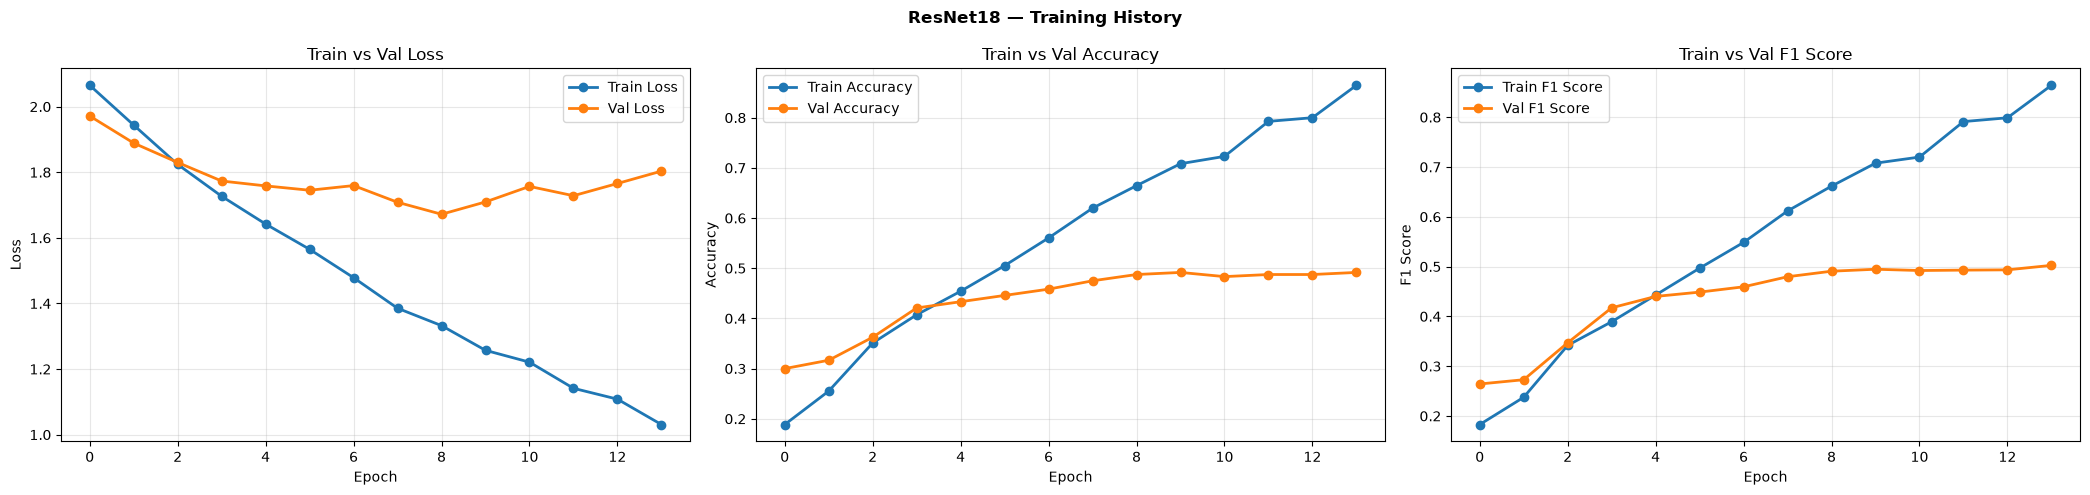


[ResNet18] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.56      0.31      0.40        16
        calm       0.62      0.78      0.69        32
       happy       0.45      0.59      0.51        32
         sad       0.29      0.22      0.25        32
       angry       0.83      0.75      0.79        32
     fearful       0.67      0.69      0.68        32
     disgust       0.55      0.53      0.54        32
   surprised       0.69      0.69      0.69        32

    accuracy                           0.59       240
   macro avg       0.58      0.57      0.57       240
weighted avg       0.58      0.59      0.58       240



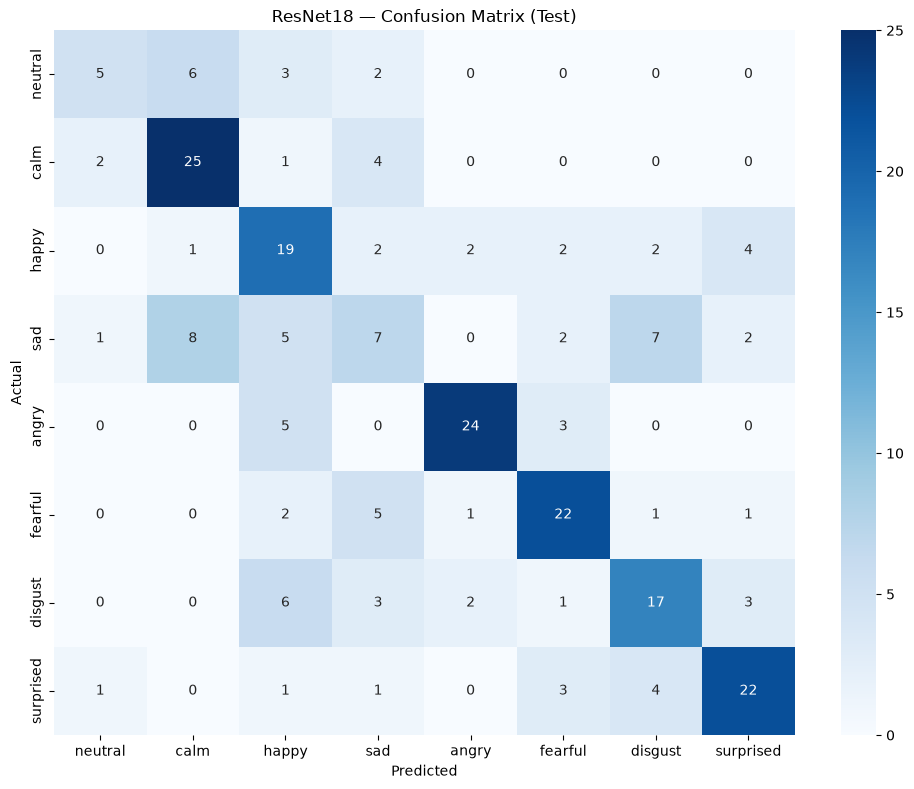

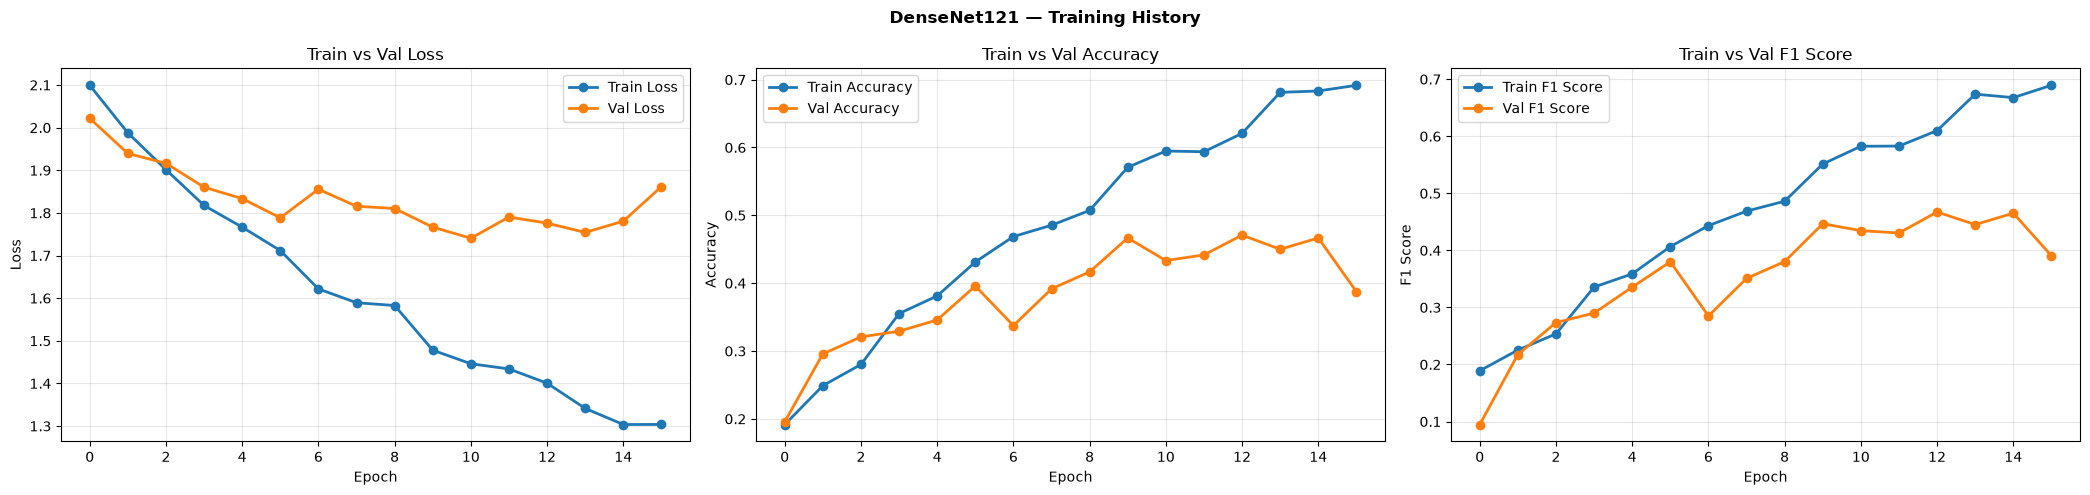


[DenseNet121] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.36      0.25      0.30        16
        calm       0.62      0.81      0.70        32
       happy       0.41      0.34      0.37        32
         sad       0.27      0.25      0.26        32
       angry       0.46      0.84      0.59        32
     fearful       0.72      0.72      0.72        32
     disgust       0.48      0.38      0.42        32
   surprised       0.79      0.34      0.48        32

    accuracy                           0.51       240
   macro avg       0.51      0.49      0.48       240
weighted avg       0.52      0.51      0.49       240



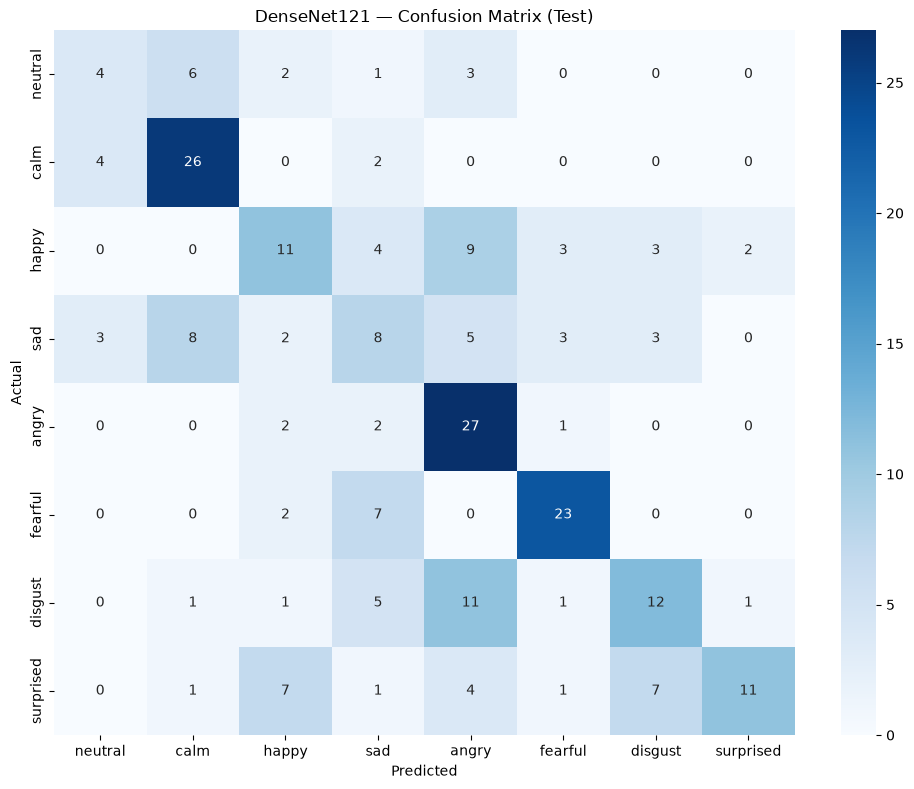

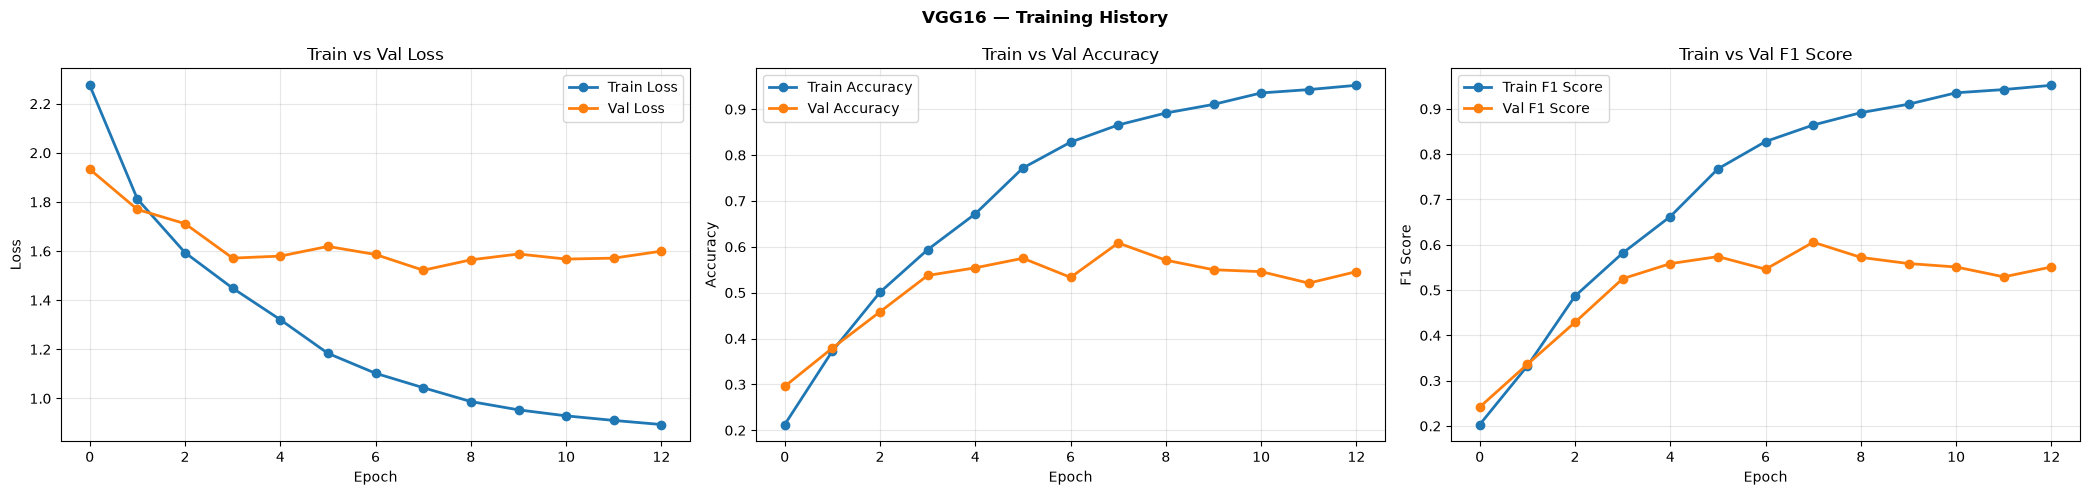


[VGG16] Classification Report (Test):
              precision    recall  f1-score   support

     neutral       0.45      0.31      0.37        16
        calm       0.65      0.75      0.70        32
       happy       0.73      0.50      0.59        32
         sad       0.38      0.16      0.22        32
       angry       0.74      0.91      0.82        32
     fearful       0.61      0.62      0.62        32
     disgust       0.44      0.84      0.57        32
   surprised       0.91      0.66      0.76        32

    accuracy                           0.61       240
   macro avg       0.61      0.59      0.58       240
weighted avg       0.62      0.61      0.60       240



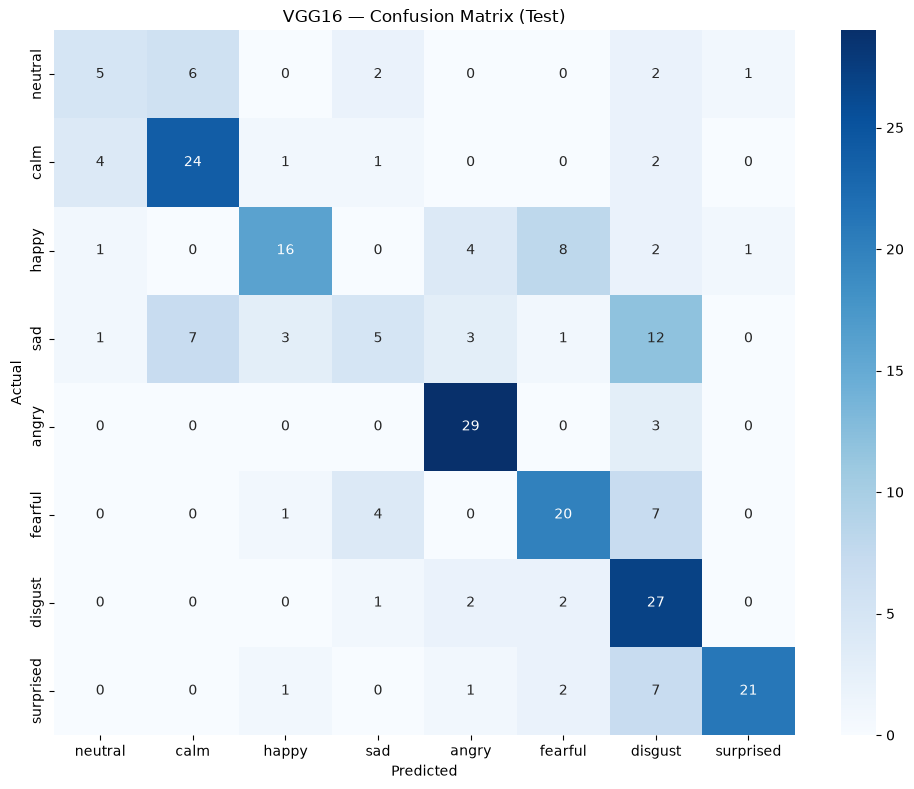

In [14]:
histories = {
    "ResNet18":    history_resnet,
    "DenseNet121": history_densenet,
    "VGG16":       history_vgg,
}

for name, model in models_dict.items():
    plot_history(histories[name], name)
    evaluate_model(model, test_loader, name)
